In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5,), (0.5,))

])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform,
download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [39:06<00:00, 72.7kB/s]


In [3]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.net = nn.Sequential(
    nn.Linear(3*32*32, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
    )
  def forward(self, x):
    x = self.flatten(x)
    return self.net(x)

In [4]:
def train(model, optimizer, epochs=10):
  model.to(device)
  loss_fn = nn.CrossEntropyLoss()
  losses = []
  accuracies = []
  for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    model.train()
    for imgs, labels in trainloader:
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs)
      loss = loss_fn(outputs, labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

      avg_loss = total_loss / len(trainloader)
      accuracy = 100.0 * correct / total
      losses.append(avg_loss)
      accuracies.append(accuracy)
      print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")
    return losses, accuracies

In [5]:
model_sgd = MLP()
sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
losses_sgd, acc_sgd = train(model_sgd, sgd)
model_adam = MLP()
adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, acc_adam = train(model_adam, adam)

Epoch 1: Loss = 0.0059, Accuracy = 14.84%
Epoch 1: Loss = 0.0117, Accuracy = 12.50%
Epoch 1: Loss = 0.0176, Accuracy = 13.28%
Epoch 1: Loss = 0.0234, Accuracy = 14.65%
Epoch 1: Loss = 0.0292, Accuracy = 16.25%
Epoch 1: Loss = 0.0349, Accuracy = 16.28%
Epoch 1: Loss = 0.0406, Accuracy = 17.19%
Epoch 1: Loss = 0.0462, Accuracy = 17.29%
Epoch 1: Loss = 0.0518, Accuracy = 18.32%
Epoch 1: Loss = 0.0575, Accuracy = 18.59%
Epoch 1: Loss = 0.0630, Accuracy = 19.11%
Epoch 1: Loss = 0.0684, Accuracy = 19.40%
Epoch 1: Loss = 0.0739, Accuracy = 19.65%
Epoch 1: Loss = 0.0794, Accuracy = 19.98%
Epoch 1: Loss = 0.0847, Accuracy = 20.42%
Epoch 1: Loss = 0.0898, Accuracy = 21.00%
Epoch 1: Loss = 0.0952, Accuracy = 21.09%
Epoch 1: Loss = 0.1007, Accuracy = 21.31%
Epoch 1: Loss = 0.1059, Accuracy = 21.75%
Epoch 1: Loss = 0.1112, Accuracy = 21.95%
Epoch 1: Loss = 0.1164, Accuracy = 22.28%
Epoch 1: Loss = 0.1217, Accuracy = 22.59%
Epoch 1: Loss = 0.1270, Accuracy = 22.55%
Epoch 1: Loss = 0.1319, Accuracy =

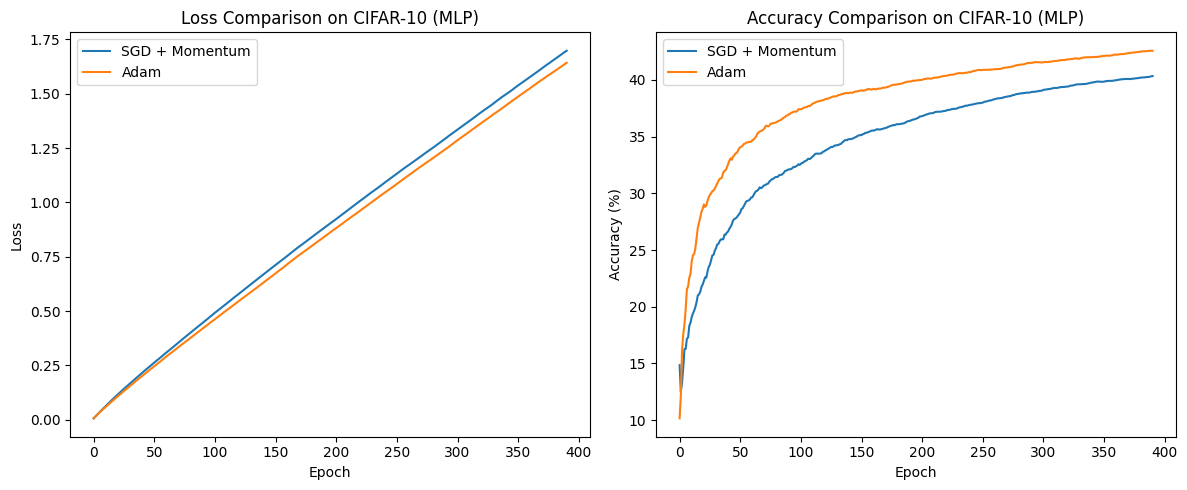

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_sgd, label="SGD + Momentum")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(acc_sgd, label="SGD + Momentum")
plt.plot(acc_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.tight_layout()
plt.show()